In [1]:
import numpy as np
import pandas as pd

In [2]:
seed0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed0_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed0["seed"] = [0 for i in range(len(seed0))]

In [3]:
seed1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed1_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed1["seed"] = [1 for i in range(len(seed1))]

In [4]:
seed2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed2_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed2["seed"] = [2 for i in range(len(seed2))]

In [5]:
seed3 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed3_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed3["seed"] = [3 for i in range(len(seed3))]

In [6]:
seed4 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed4_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed4["seed"] = [4 for i in range(len(seed4))]

In [7]:
seed5 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed5_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed5["seed"] = [5 for i in range(len(seed5))]

In [8]:
seed6 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed6_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed6["seed"] = [6 for i in range(len(seed6))]

In [9]:
seed7 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed7_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed7["seed"] = [7 for i in range(len(seed7))]

In [10]:
seed8 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed8_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed8["seed"] = [8 for i in range(len(seed8))]

In [11]:
seed9 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/seeds/seed9_fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

seed9["seed"] = [9 for i in range(len(seed9))]

In [12]:
df = pd.concat([seed0, seed1, seed2, seed3, seed4, 
                seed5, seed6, seed7, seed8, seed9], ignore_index=True)

In [13]:
import ast

In [14]:
df['positions'] = df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [15]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [16]:
df = df[df["num_edits"] > 0]

In [17]:
df = df[df["URQ_diff"] < -0.05]

In [18]:
len(df)

399

In [19]:
def combine_positions_orientations(row):
    """Turn positions + orientations into set of tuples (start, end, strand)."""
    pos = row["positions"]
    ori = row["orientation"]
    return {(s, e, o) for (s, e), o in zip(pos, ori)}

In [20]:
# Make a new column with motif sets
df["motif_set"] = df.apply(combine_positions_orientations, axis=1)

In [21]:
import itertools

In [22]:
import matplotlib.pyplot as plt

In [23]:
region_cols = ['chrom', 'centered_start', 'centered_end']
region_keys = df[region_cols].drop_duplicates().to_dict('records')

results = []

for region in region_keys:
    region_df = df[
        (df['chrom'] == region['chrom']) &
        (df['centered_start'] == region['centered_start']) &
        (df['centered_end'] == region['centered_end'])
    ]
    
    seed_to_sites = {row['seed']: row['motif_set'] for _, row in region_df.iterrows()}

    for seed1, seed2 in itertools.combinations(sorted(seed_to_sites.keys()), 2):
        set1 = seed_to_sites[seed1]
        set2 = seed_to_sites[seed2]
        intersection = len(set1 & set2)
        union = len(set1 | set2)
        jaccard = intersection / union if union > 0 else float('nan')
        results.append({
            **region,
            'seed1': seed1,
            'seed2': seed2,
            'jaccard': jaccard
        })

jaccard_df = pd.DataFrame(results)

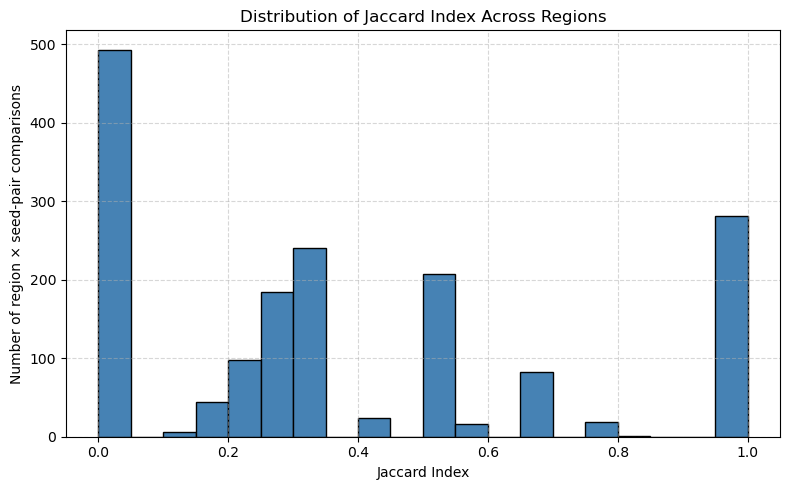

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(jaccard_df['jaccard'].dropna(), bins=20, color='steelblue', edgecolor='black')
plt.xlabel('Jaccard Index')
plt.ylabel('Number of region × seed-pair comparisons')
plt.title('Distribution of Jaccard Index Across Regions')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [25]:
import random

region_keys = df[['chrom', 'centered_start', 'centered_end']].drop_duplicates()
random_regions = region_keys.sample(5, random_state=40).to_dict('records')

In [26]:
def get_jaccard_matrix_from_df(region, jaccard_df):
    region_mask = (
        (jaccard_df['chrom'] == region['chrom']) &
        (jaccard_df['centered_start'] == region['centered_start']) &
        (jaccard_df['centered_end'] == region['centered_end'])
    )
    sub_df = jaccard_df[region_mask]
    seeds = sorted(set(sub_df['seed1']) | set(sub_df['seed2']))
    matrix = pd.DataFrame(np.eye(len(seeds)), index=seeds, columns=seeds)

    for _, row in sub_df.iterrows():
        s1, s2 = row['seed1'], row['seed2']
        matrix.loc[s1, s2] = row['jaccard']
        matrix.loc[s2, s1] = row['jaccard']  # symmetric

    return matrix

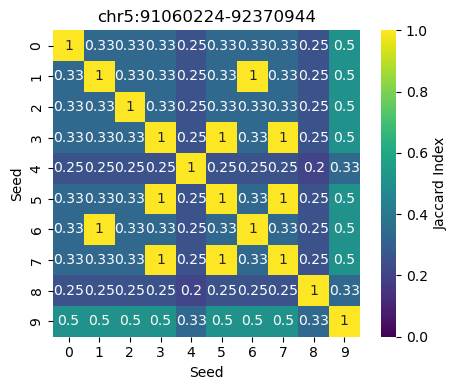

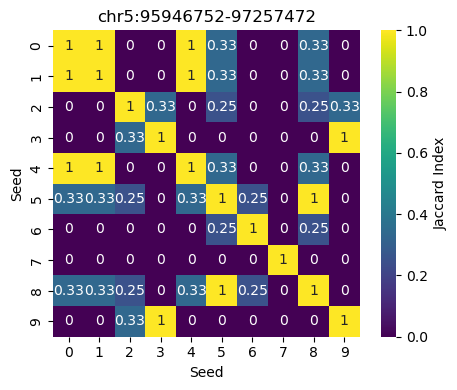

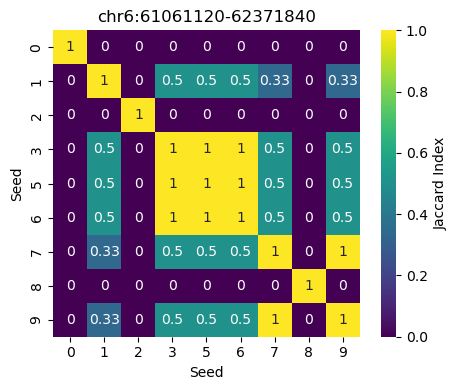

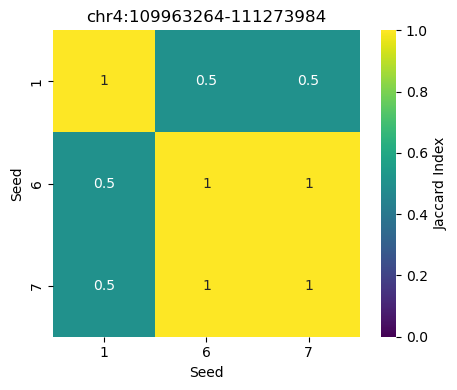

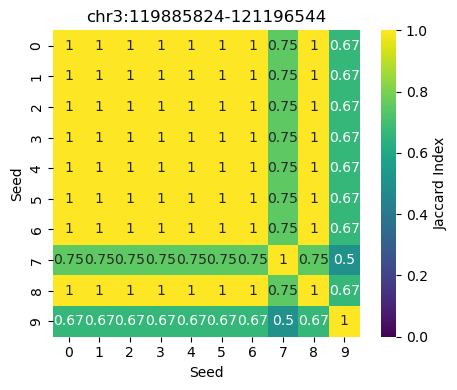

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

for region in random_regions:
    mat = get_jaccard_matrix_from_df(region, jaccard_df)

    plt.figure(figsize=(5, 4))
    sns.heatmap(mat, annot=True, cmap='viridis', vmin=0, vmax=1, square=True,
                xticklabels=mat.columns, yticklabels=mat.index,
                cbar_kws={'label': 'Jaccard Index'})
    plt.title(f"{region['chrom']}:{region['centered_start']}-{region['centered_end']}")
    plt.xlabel("Seed")
    plt.ylabel("Seed")
    plt.tight_layout()
    plt.show()

In [28]:
# collecting all CTCFs

import pandas as pd

bin_size = 2048
center_offset = 320 * bin_size
flank = 60
motif_len = 19

In [29]:
ctcf_records = []

for idx, row in df.iterrows():
    chrom = row['chrom']
    win_start = row['centered_start']
    win_end = row['centered_end']
    seed = row['seed']
    ctcf_sites = row['positions']
    orientations = list(row['orientation']) if isinstance(row['orientation'], str) else []

    if isinstance(ctcf_sites, str):
        try:
            ctcf_sites = eval(ctcf_sites)
        except:
            continue

    for i, (rel_start, rel_end) in enumerate(ctcf_sites):
        orientation = orientations[i] if i < len(orientations) else '?'
        ctcf_records.append({
            'chrom': chrom,
            'centered_start': win_start,
            'centered_end': win_end,
            'rel_start': rel_start,
            'rel_end': rel_end,
            'orientation': orientation,
            'seed': seed
        })

ctcf_df = pd.DataFrame(ctcf_records)


In [30]:
# Count number of unique seeds in which each site appears
ctcf_seed_counts = (
    ctcf_df
    .groupby(['chrom', 'centered_start', 'centered_end', 'rel_start', 'rel_end', 'orientation'])
    .agg(seeds_present=('seed', 'nunique'))
    .reset_index()
)

In [31]:
ctcf_seed_counts['fraction_across_seeds'] = ctcf_seed_counts['seeds_present'] / 10

In [32]:
ctcf_seed_counts['genomic_start'] = ctcf_seed_counts['centered_start'] + center_offset - flank + ctcf_seed_counts['rel_start']
ctcf_seed_counts['genomic_end'] = ctcf_seed_counts['centered_start'] + center_offset - flank + ctcf_seed_counts['rel_end']

In [33]:
ctcf_seed_counts

,chrom,centered_start,centered_end,rel_start,rel_end,orientation,seeds_present,fraction_across_seeds,genomic_start,genomic_end
0,chr1,37799936,39110656,66,85,-,1,0.1,38455302,38455321
1,chr1,37799936,39110656,644,663,-,3,0.3,38455880,38455899
2,chr1,37799936,39110656,1125,1144,+,3,0.3,38456361,38456380
3,chr1,37799936,39110656,1179,1198,+,2,0.2,38456415,38456434
4,chr1,37799936,39110656,1506,1525,-,2,0.2,38456742,38456761
...,...,...,...,...,...,...,...,...,...,...
372,chrX,48441344,49752064,1428,1447,-,1,0.1,49098072,49098091
373,chrX,48441344,49752064,1436,1455,+,7,0.7,49098080,49098099
374,chrX,60768256,62078976,1771,1790,+,2,0.2,61425327,61425346
375,chrX,60768256,62078976,1816,1835,+,10,1.0,61425372,61425391


In [35]:
from pyfaidx import Fasta

In [36]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [37]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices, dtype=int)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    return one_hot_encoded

In [38]:
def get_sequence(genome, chrom, start, end):
    seq = genome[chrom][start:end].seq.upper()
    ohe_seq = one_hot_encode_sequence(seq)
    return np.expand_dims(ohe_seq, axis=0)

In [39]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [40]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [41]:
import torch

In [42]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [43]:
from tangermeme.tools import fimo

In [44]:
all_hits = []
padding = 10

for idx, row in ctcf_seed_counts.iterrows():
    chrom = row["chrom"]
    site_start = row["genomic_start"]
    site_end = row["genomic_end"]
    site_orient = row["orientation"]
    seeds_frac = row["fraction_across_seeds"]
    
    sequence = get_sequence(genome, chrom, site_start-padding, site_end+padding)
    
    hits = fimo.fimo(
        motifs=motifs_dict,
        sequences=sequence,
        threshold=0.1,
        reverse_complement=True
    )[0]
    
    # Only add non-empty results
    if not hits.empty:
        hits["chrom"] = chrom
        hits["start"] = site_start
        hits["end"] = site_end
        hits["orientation"] = site_orient
        hits["fraction_across_seeds"] = seeds_frac
        all_hits.append(hits)

In [45]:
combined_hits_df = pd.concat(all_hits, ignore_index=True)

In [46]:
hits_same_orient = combined_hits_df[combined_hits_df["strand"] == combined_hits_df["orientation"]]

In [47]:
hits_same_orient["neglog10_p"] = -np.log10(hits_same_orient["p-value"])

/tmp/SLURM_1708899/ipykernel_165563/2903195711.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hits_same_orient["neglog10_p"] = -np.log10(hits_same_orient["p-value"])


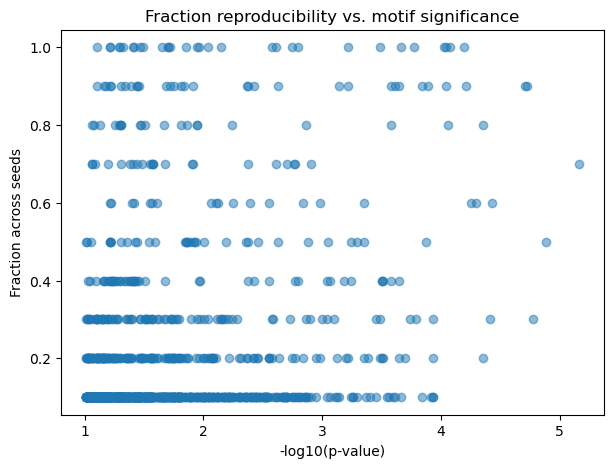

In [48]:
plt.figure(figsize=(7,5))
plt.scatter(
    hits_same_orient["neglog10_p"],
    hits_same_orient["fraction_across_seeds"],
    alpha=0.5
)
plt.xlabel("-log10(p-value)")
plt.ylabel("Fraction across seeds")
plt.title("Fraction reproducibility vs. motif significance")
plt.show()

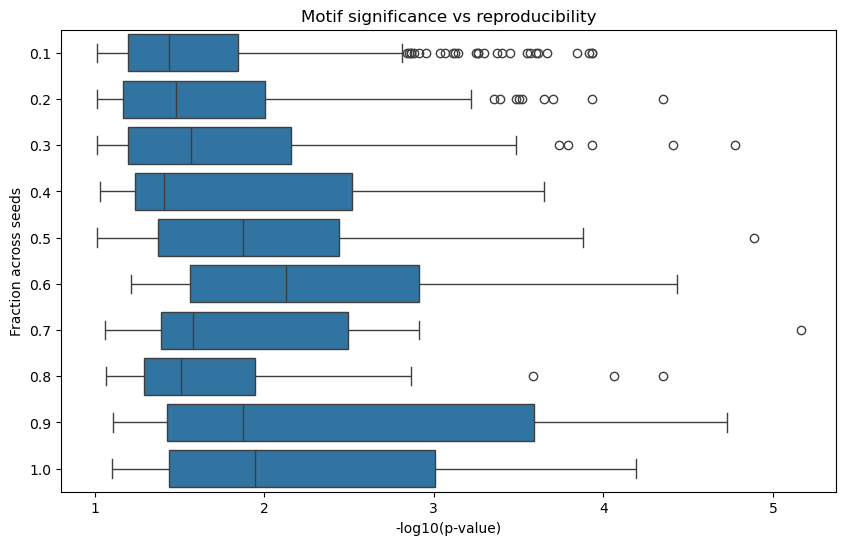

In [49]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=hits_same_orient,
    x="neglog10_p",
    y="fraction_across_seeds",
    orient="h"  # horizontal boxes
)
plt.xlabel("-log10(p-value)")
plt.ylabel("Fraction across seeds")
plt.title("Motif significance vs reproducibility")
plt.show()

In [50]:
# Define fixed-width bins (10 bins across range of neglog10_p)
bins = np.linspace(hits_same_orient["neglog10_p"].min(),
                   hits_same_orient["neglog10_p"].max(),
                   6)
hits_same_orient["p_bin"] = pd.cut(hits_same_orient["neglog10_p"], bins=bins, include_lowest=True)

# Optional: nicer bin labels (midpoints)
bin_labels = [f"{b.left:.1f}–{b.right:.1f}" for b in hits_same_orient["p_bin"].cat.categories]
hits_same_orient["p_bin_label"] = hits_same_orient["p_bin"].cat.rename_categories(bin_labels)

/tmp/SLURM_1708899/ipykernel_165563/816028610.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hits_same_orient["p_bin"] = pd.cut(hits_same_orient["neglog10_p"], bins=bins, include_lowest=True)
/tmp/SLURM_1708899/ipykernel_165563/816028610.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hits_same_orient["p_bin_label"] = hits_same_orient["p_bin"].cat.rename_categories(bin_labels)


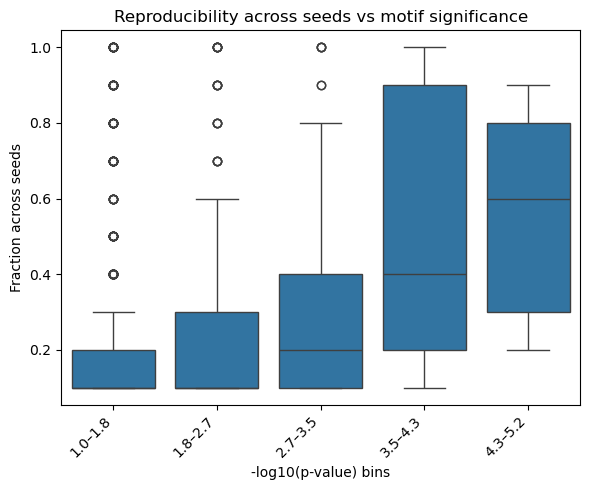

In [51]:
# Plot
plt.figure(figsize=(6,5))
sns.boxplot(
    data=hits_same_orient,
    x="p_bin_label",
    y="fraction_across_seeds"
)
plt.xlabel("-log10(p-value) bins")
plt.ylabel("Fraction across seeds")
plt.title("Reproducibility across seeds vs motif significance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

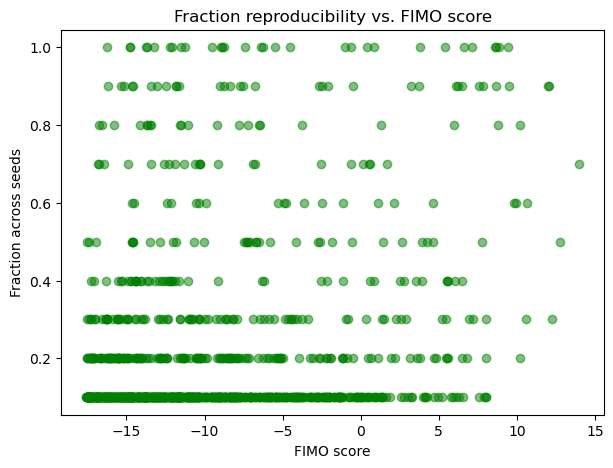

In [52]:
plt.figure(figsize=(7,5))
plt.scatter(
    hits_same_orient["score"],
    hits_same_orient["fraction_across_seeds"],
    alpha=0.5,
    color="green"
)
plt.xlabel("FIMO score")
plt.ylabel("Fraction across seeds")
plt.title("Fraction reproducibility vs. FIMO score")
plt.show()

In [57]:
from scipy.stats import pearsonr

In [ ]:
df

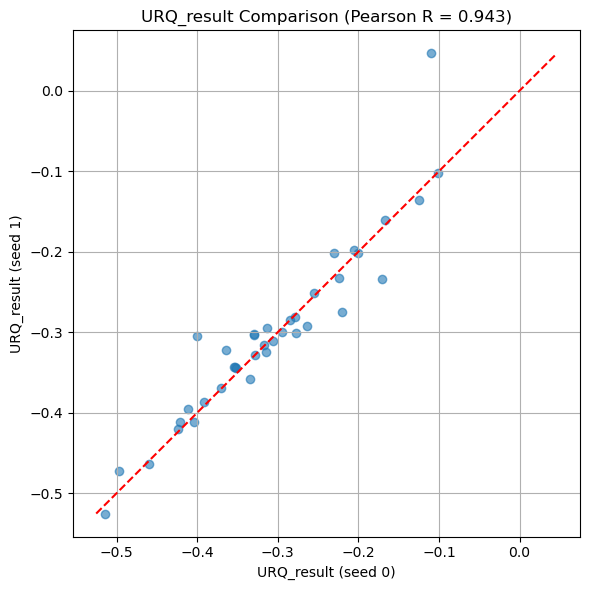

In [58]:
# Pivot to align seed 0 and seed 1 by region
pivot_df = df[df['seed'].isin([0, 1])].pivot_table(
    index=['chrom', 'centered_start', 'centered_end'], 
    columns='seed', 
    values='URQ_result'
).dropna()

pivot_df.columns = ['seed0', 'seed1']

# Calculate Pearson R
r, pval = pearsonr(pivot_df['seed0'], pivot_df['seed1'])

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['seed0'], pivot_df['seed1'], alpha=0.6)
plt.plot([pivot_df.min().min(), pivot_df.max().max()],
         [pivot_df.min().min(), pivot_df.max().max()], 'r--')  # identity line

plt.xlabel('URQ_result (seed 0)')
plt.ylabel('URQ_result (seed 1)')
plt.title(f'URQ_result Comparison (Pearson R = {r:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

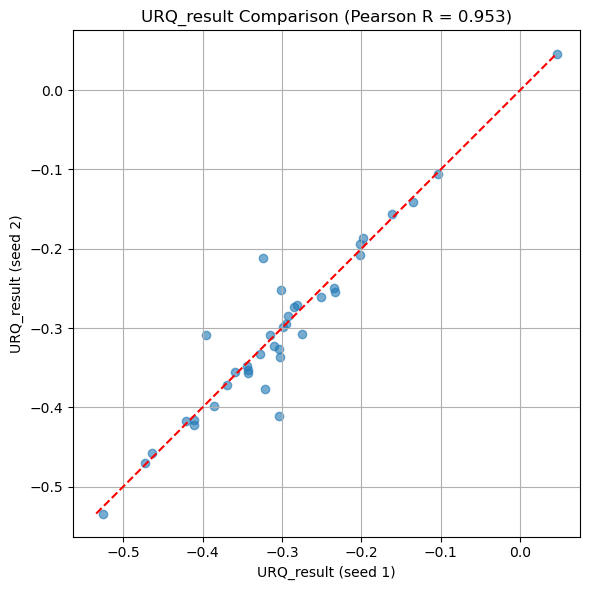

In [59]:
# Pivot to align seed 1 and seed 2 by region
pivot_df = df[df['seed'].isin([1, 2])].pivot_table(
    index=['chrom', 'centered_start', 'centered_end'], 
    columns='seed', 
    values='URQ_result'
).dropna()

pivot_df.columns = ['seed1', 'seed2']

# Calculate Pearson R
r, pval = pearsonr(pivot_df['seed1'], pivot_df['seed2'])

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['seed1'], pivot_df['seed2'], alpha=0.6)
plt.plot([pivot_df.min().min(), pivot_df.max().max()],
         [pivot_df.min().min(), pivot_df.max().max()], 'r--')  # identity line

plt.xlabel('URQ_result (seed 1)')
plt.ylabel('URQ_result (seed 2)')
plt.title(f'URQ_result Comparison (Pearson R = {r:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

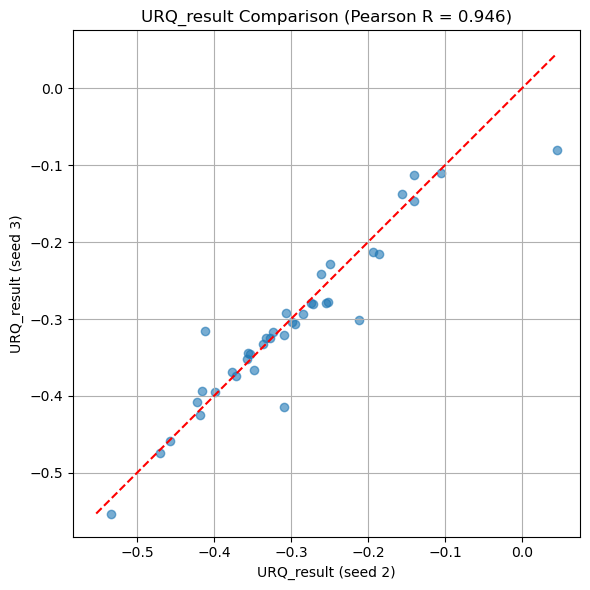

In [60]:
# Pivot to align seed 2 and seed 3 by region
pivot_df = df[df['seed'].isin([2, 3])].pivot_table(
    index=['chrom', 'centered_start', 'centered_end'], 
    columns='seed', 
    values='URQ_result'
).dropna()

pivot_df.columns = ['seed2', 'seed3']

# Calculate Pearson R
r, pval = pearsonr(pivot_df['seed2'], pivot_df['seed3'])

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['seed2'], pivot_df['seed3'], alpha=0.6)
plt.plot([pivot_df.min().min(), pivot_df.max().max()],
         [pivot_df.min().min(), pivot_df.max().max()], 'r--')  # identity line

plt.xlabel('URQ_result (seed 2)')
plt.ylabel('URQ_result (seed 3)')
plt.title(f'URQ_result Comparison (Pearson R = {r:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

In [61]:
region_cols = ['chrom', 'centered_start', 'centered_end']
aligned_df = df.pivot_table(index=region_cols, columns='seed', values=['orientation', 'positions'], aggfunc='first')
aligned_df = aligned_df.dropna()  # keep only complete pairs

In [ ]:
# aligned_df

In [62]:
region = ('chr1', 37799936, 39110656)  # replace with actual centered region
region_df = df[
    (df['chrom'] == region[0]) &
    (df['centered_start'] == region[1]) &
    (df['centered_end'] == region[2])]

/tmp/SLURM_1708899/ipykernel_165563/2515519180.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['positions'] = region_df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)


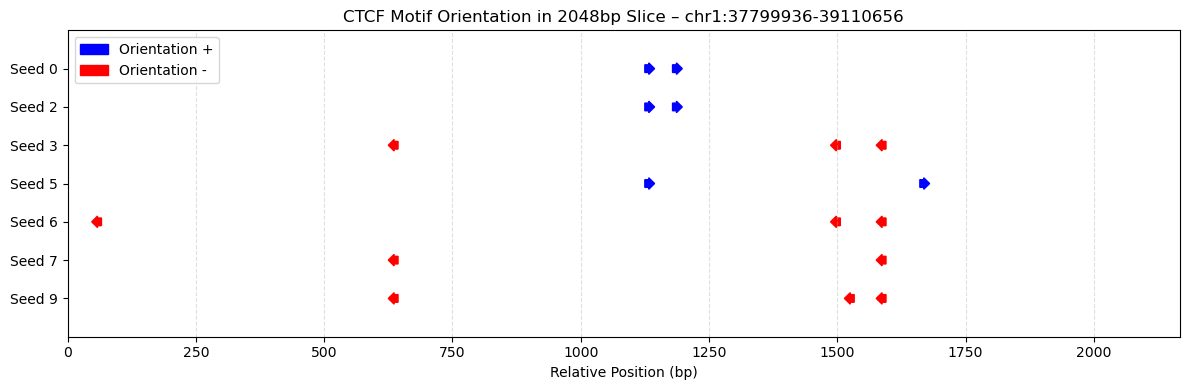

In [72]:
from matplotlib.patches import FancyArrow, Patch
import ast

# --- Choose a region ---
region = ('chr1', 37799936, 39110656)  # replace with actual centered region
region_df = df[
    (df['chrom'] == region[0]) &
    (df['centered_start'] == region[1]) &
    (df['centered_end'] == region[2]) &
    (df['seed'].isin([0, 2, 3, 5, 6, 7, 9]))
]

# --- Parse positions if needed ---
region_df['positions'] = region_df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(12, 4))  # taller for more rows
seed_order = [9, 7, 6, 5, 3, 2, 0]
y_positions = {seed: idx for idx, seed in enumerate(seed_order)}  # top-down: 5 → 0

# --- Draw motifs ---
for _, row in region_df.iterrows():
    seed = row['seed']
    y = y_positions[seed]
    positions = row['positions']
    orientations = row['orientation']
    
    for (start, end), ori in zip(positions, orientations):
        color = 'blue' if ori == '+' else 'red'
        direction = 1 if ori == '+' else -1
        width = end - start
        arrow = FancyArrow(start, y, width * direction, 0,
                           width=0.2,
                           head_width=0.3,
                           head_length=min(20, width * 0.6),
                           length_includes_head=True,
                           color=color)
        ax.add_patch(arrow)

# --- Axis settings ---
ax.set_xlim(0, 2168)
ax.set_ylim(-1, len(seed_order))
ax.set_yticks([y_positions[s] for s in seed_order])
ax.set_yticklabels([f'Seed {s}' for s in seed_order])
ax.set_xlabel('Relative Position (bp)')
ax.set_title(f"CTCF Motif Orientation in 2048bp Slice – {region[0]}:{region[1]}-{region[2]}")
ax.grid(axis='x', linestyle='--', alpha=0.4)

# --- Legend ---
legend_handles = [
    Patch(color='blue', label='Orientation +'),
    Patch(color='red', label='Orientation -')
]
ax.legend(handles=legend_handles, loc='upper left')

plt.tight_layout()

# --- Save as SVG ---
# plt.savefig("ctcf_seeds_orientations.svg", format="svg", bbox_inches="tight")

plt.show()


In [105]:
region_df[region_df["seed"] == 9]

,chrom,fold,PearsonR,centered_start,centered_end,centered_flat_start,centered_flat_end,active_fraction,neutral_fraction,repressive_fraction,...,GC_slice_edited,init_CTCFs_num,CTCFs_num,FIMO_sum,FIMO_max,orientation,positions,seed,URQ_diff,motif_set
414,chr1,fold0,0.861165,37799936,39110656,192,320,0.391304,0.521739,0.086957,...,0.464355,0,3,55.401327,23.656287,---,"[(644, 663), (1533, 1552), (1595, 1614)]",9,-0.164843,"{(1595, 1614, -), (644, 663, -), (1533, 1552, -)}"


### Check underlying sequence

In [54]:
# df

In [81]:
chrom = "chr1"
start = 37799936
end = 39110656	

In [82]:
path_to_ohe_seq = f"/scratch1/smaruj/generate_genomic_boundary/ohe_X/fold0/{chrom}_{start}_{end}_X.pt"

In [83]:
import torch

In [84]:
ohe = torch.load(path_to_ohe_seq)

/tmp/SLURM_1708899/ipykernel_165563/1069704943.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ohe = torch.load(path_to_ohe_seq)


In [90]:
central_bin = 256
cropping = 64
bins_size = 2048

In [89]:
extra_flank = 60

In [91]:
scanned_slice_start = ((central_bin + cropping) * bins_size) - extra_flank

In [92]:
scanned_slice_end = ((central_bin + cropping + 1) * bins_size) + extra_flank

In [93]:
ohe_slice = ohe[:, :, scanned_slice_start:scanned_slice_end]

In [107]:
# check_for_ctcf = ohe_slice[0, :, 1661:1680]
# check_for_ctcf = ohe_slice[0, :, 644:663]
# check_for_ctcf = ohe_slice[0, :, 1125:1144]
check_for_ctcf = ohe_slice[0, :, 1595:1614]

check_for_ctcf_np = check_for_ctcf.numpy()

In [108]:
check_for_ctcf_np

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1.,
        0., 0., 0.],
       [0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
        1., 0., 0.],
       [1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 1., 1.]], dtype=float32)

In [109]:
def decode_ohe_dna(ohe_array, reverse_complement=False):
    """
    Decode a one-hot encoded DNA array (shape: 4 x seq_len) into a string.
    If reverse_complement=True, returns the reverse complement of the sequence.
    """
    # Map from channel index to base
    index_to_base = ['A', 'C', 'G', 'T']
    
    # Decode from one-hot
    base_indices = np.argmax(ohe_array, axis=0)
    sequence = ''.join(index_to_base[i] for i in base_indices)
    
    if reverse_complement:
        # Define complement map
        complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
        sequence = ''.join(complement[base] for base in reversed(sequence))
    
    return sequence

In [110]:
decoded = decode_ohe_dna(check_for_ctcf_np, reverse_complement=True)

In [111]:
decoded_sequence = ''.join(decoded)
print(decoded_sequence)

AAGTTCTCAGGGGGAGCTC
